In [1]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("Device count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

CUDA available: True
CUDA version: 12.1
Device count: 1
GPU name: NVIDIA GeForce RTX 4060 Laptop GPU


In [3]:
import pandas as pd
import os
import sys
from pathlib import Path
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
%load_ext autoreload
%autoreload 2

In [5]:
# Display all columns
pd.set_option('display.max_columns', None)

# Display all rows
pd.set_option('display.max_rows', None)

# Set the width to show all content in each cell
pd.set_option('display.width', None)

# Set the max string length to display
pd.set_option('display.max_colwidth', None)

In [6]:
sys.path.append('C:/Users/rishe/Dissertation')

In [7]:
EXP_ID = f'exp_4_lstm_focal_loss'
DATA_PATH = f'C:/Users/rishe/Dissertation/data/processed_rain.parquet'

In [8]:
df_long = pd.read_parquet(DATA_PATH)

In [9]:
df_long.shape

(4741665, 11)

In [10]:
df_long['station_id'].nunique()

293

### Data Pre-processing

In [11]:
df_long.head()

,station_id,date,year,month,day,day_of_year,rainfall,lat,lon,district,station_type
0,AKRIGANJ,1901-01-01,1901,1,1,1,4.1,NaN,NaN,MURSHIDABAD,None
1,AKRIGANJ,1901-01-02,1901,1,2,2,3.3,NaN,NaN,MURSHIDABAD,None
2,AKRIGANJ,1901-01-03,1901,1,3,3,0.3,NaN,NaN,MURSHIDABAD,None
3,AKRIGANJ,1901-01-04,1901,1,4,4,0.3,NaN,NaN,MURSHIDABAD,None
4,AKRIGANJ,1901-01-05,1901,1,5,5,0.0,NaN,NaN,MURSHIDABAD,None


In [12]:
df_long.isna().sum()

station_id            0
date                  0
year                  0
month                 0
day                   0
day_of_year           0
rainfall         782517
lat              116514
lon              116514
district              0
station_type    2977122
dtype: int64

In [13]:
df_long = df_long.dropna(subset=['rainfall'])

In [14]:
station_summary = df_long.groupby('station_id').agg(
    data_available_in_days=('rainfall', 'count'),
    rainy_days=('rainfall', lambda x: (x > 0).sum())
).reset_index()

In [15]:
station_summary.head()

,station_id,data_available_in_days,rainy_days
0,AKRIGANJ,15713,3599
1,ALGARAH,13575,5625
2,ALIPUR,43752,14650
3,ALIPURDUAR,34602,11853
4,ALIPURDUAR(CWC),4937,1847


In [16]:
station_summary['rainy_days'].sum()

1121149

### Data Splits

In [17]:
from utils.data_utils.data_helper_utils import temporal_split

In [18]:
df_train, df_val, df_test = temporal_split(df_long)

### Dataset Preparation

In [19]:
from utils.data_utils.dataset_files.dataset_with_meta_features import RainfallWindowDataset

In [20]:
# Experiment configuration
H = 1  # Horizon
L = 30  # Window length
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Device: {device}")
print(f"Window length: {L}")
print(f"Horizon: {H}")

Device: cuda
Window length: 30
Horizon: 1


In [21]:
train_ds = RainfallWindowDataset(
    df_train,
    window_length=L,
    horizon=H,
    min_days_per_station=L + H
)

val_ds = RainfallWindowDataset(
    df_val,
    window_length=L,
    horizon=H,
    min_days_per_station=L + H
)

test_ds = RainfallWindowDataset(
    df_test,
    window_length=L,
    horizon=H,
    min_days_per_station=L + H
)

print(f"Train samples: {len(train_ds)}")
print(f"Val samples: {len(val_ds)}")
print(f"Test samples: {len(test_ds)}")

Train samples: 2762479
Val samples: 585253
Test samples: 585402


### Import Loss Functions and Models

In [26]:
# Import custom loss function
from utils.loss import FocalMSELoss

# Import model trainer that accepts custom criterion
from models.lstm_with_custom_criterion import RainfallLSTM, train_model, collect_test_predictions, evaluate_on_test

# Import metrics
from utils.metric_utils.metrics import rmse, mae, bias, nrmse, seasonal_subset, stationwise_metrics

print("Imports successful!")

Imports successful!


### Training with Focal Loss

In [27]:
# Focal loss configuration
FOCAL_GAMMA = 2.0
criterion = FocalMSELoss(gamma=FOCAL_GAMMA, reduction='mean')

print(f"Criterion: FocalMSELoss (gamma={FOCAL_GAMMA})")
print(f"Criterion type: {type(criterion)}")

Criterion: FocalMSELoss (gamma=2.0)
Criterion type: <class 'utils.loss.FocalMSELoss'>


In [28]:
# Model configuration
BATCH_SIZE = 64
EPOCHS = 10
LEARNING_RATE = 1e-3
HIDDEN_DIM = 128

# Setup paths
model_save_path = f"C:/Users/rishe/Dissertation/experiments/saved_models/{EXP_ID}"
log_save_path = f"C:/Users/rishe/Dissertation/experiments/logs/{EXP_ID}"

print(f"Model save path: {model_save_path}")
print(f"Log save path: {log_save_path}")

Model save path: C:/Users/rishe/Dissertation/experiments/saved_models/exp_4_lstm_focal_loss
Log save path: C:/Users/rishe/Dissertation/experiments/logs/exp_4_lstm_focal_loss


In [29]:
# Create model
model = RainfallLSTM(
    input_dim=train_ds.X.shape[-1],
    hidden_dim=HIDDEN_DIM
).to(device)

print(f"Model created successfully")
print(f"Input dim: {train_ds.X.shape[-1]}")
print(f"Hidden dim: {HIDDEN_DIM}")

Model created successfully
Input dim: 7
Hidden dim: 128


In [30]:
# Train model with focal loss as criterion
from datetime import datetime

print(f"\n{'='*60}")
print(f"Starting training with FocalMSELoss")
print(f"Start time: {datetime.now()}")
print(f"{'='*60}")

trained_model = train_model(
    train_ds=train_ds,
    val_ds=val_ds,
    model=model,
    device=device,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    criterion=criterion,  # Pass FocalMSELoss as criterion
    save_dir=model_save_path,
    log_dir=log_save_path,
    experiment_name=EXP_ID
)

print(f"\nEnd time: {datetime.now()}")
print(f"Training completed successfully!")


Starting training with FocalMSELoss
Start time: 2026-02-08 20:54:12.016610
2026-02-08 20:54:12 | INFO | Starting training
2026-02-08 20:54:12 | INFO | Device: cuda


Epochs:   0%|          | 0/10 [00:00<?, ?it/s]

2026-02-08 20:57:00 | INFO | Epoch 001 | Train Loss: 235.431140 | Val Loss: 247.398578
2026-02-08 20:57:00 | INFO | Checkpoint saved: C:/Users/rishe/Dissertation/experiments/saved_models/exp_4_lstm_focal_loss\epoch_1.pt
2026-02-08 20:59:43 | INFO | Epoch 002 | Train Loss: 233.902640 | Val Loss: 246.061359
2026-02-08 20:59:43 | INFO | Checkpoint saved: C:/Users/rishe/Dissertation/experiments/saved_models/exp_4_lstm_focal_loss\epoch_2.pt
2026-02-08 21:02:25 | INFO | Epoch 003 | Train Loss: 233.701612 | Val Loss: 247.001571
2026-02-08 21:02:25 | INFO | Checkpoint saved: C:/Users/rishe/Dissertation/experiments/saved_models/exp_4_lstm_focal_loss\epoch_3.pt
2026-02-08 21:04:42 | INFO | Epoch 004 | Train Loss: 233.533167 | Val Loss: 246.914815
2026-02-08 21:04:42 | INFO | Checkpoint saved: C:/Users/rishe/Dissertation/experiments/saved_models/exp_4_lstm_focal_loss\epoch_4.pt
2026-02-08 21:06:59 | INFO | Epoch 005 | Train Loss: 233.447284 | Val Loss: 246.659821
2026-02-08 21:06:59 | INFO | Chec

In [31]:
# Evaluate on test set
print(f"\n{'='*60}")
print(f"Evaluating on test set")
print(f"{'='*60}")

test_metrics = evaluate_on_test(
    test_ds,
    trained_model,
    device
)

print("\nTest Metrics:")
for metric_name, metric_value in test_metrics.items():
    print(f"{metric_name}: {metric_value:.4f}")


Evaluating on test set
2026-02-08 22:03:58 | INFO | Overall Test Metrics
2026-02-08 22:03:58 | INFO | RMSE: 15.8139
2026-02-08 22:03:58 | INFO | MAE: 6.6286
2026-02-08 22:03:58 | INFO | Bias: -0.2701
2026-02-08 22:03:58 | INFO | NRMSE: 2.8250
2026-02-08 22:03:58 | INFO | MONSOON RMSE: 23.0241
2026-02-08 22:03:58 | INFO | NON_MONSOON RMSE: 8.7056

Test Metrics:
RMSE: 15.8139
MAE: 6.6286
Bias: -0.2701
NRMSE: 2.8250
monsoon_RMSE: 23.0241
non_monsoon_RMSE: 8.7056


### Evaluation

In [32]:
# Load best checkpoint (epoch 9)
ckpt_path = f"{model_save_path}/epoch_9.pt"
print(f"Loading checkpoint: {ckpt_path}")

checkpoint = torch.load(ckpt_path, map_location=device)
trained_model.load_state_dict(checkpoint["model_state_dict"])
trained_model.to(device)
trained_model.eval()

print("Checkpoint loaded successfully!")

Loading checkpoint: C:/Users/rishe/Dissertation/experiments/saved_models/exp_4_lstm_focal_loss/epoch_9.pt
Checkpoint loaded successfully!


C:\Users\rishe\AppData\Local\Temp\ipykernel_37136\3334625799.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(ckpt_path, map_location=device)


In [33]:
# Collect test predictions
df_eval = collect_test_predictions(
    test_ds=test_ds,
    model=trained_model,
    device=device
)

print(f"Predictions collected: {len(df_eval)} samples")
df_eval.head()

Predictions collected: 585402 samples


,y,yhat,month,station_id,lat,lon
0,0.0,7.696614,8,AKRIGANJ,NaN,NaN
1,0.0,7.810820,8,AKRIGANJ,NaN,NaN
2,0.0,8.102279,8,AKRIGANJ,NaN,NaN
3,0.0,7.494650,8,AKRIGANJ,NaN,NaN
4,4.8,7.288199,8,AKRIGANJ,NaN,NaN


In [34]:
# Calculate error metrics
df_eval["error"] = df_eval["y"] - df_eval["yhat"]

# Create masks for analysis
rainy_mask = df_eval["y"] > 0
non_rainy_mask = df_eval["y"] == 0

monsoon_months = [6, 7, 8, 9]
non_monsoon_months = [1, 2, 3, 4, 5, 10, 11, 12]

monsoon_mask = df_eval["month"].isin(monsoon_months)
non_monsoon_mask = df_eval["month"].isin(non_monsoon_months)

print("Error metrics and masks calculated")

Error metrics and masks calculated


### Overall Evaluation Metrics

In [35]:
overall_metrics = {
    "RMSE": rmse(df_eval.y.values, df_eval.yhat.values),
    "MAE": mae(df_eval.y.values, df_eval.yhat.values),
    "Bias": bias(df_eval.y.values, df_eval.yhat.values),
    "NRMSE": nrmse(df_eval.y.values, df_eval.yhat.values),
}

print("\nOverall Evaluation Metrics (FocalMSELoss):")
print(pd.DataFrame(overall_metrics, index=["Focal Loss Model"]).round(4))


Overall Evaluation Metrics (FocalMSELoss):
                     RMSE     MAE    Bias  NRMSE
Focal Loss Model  15.8251  6.9027  0.1438  2.827


### Seasonal Evaluation

In [36]:
df_monsoon = seasonal_subset(df_eval, monsoon_months)
df_non_monsoon = seasonal_subset(df_eval, non_monsoon_months)

seasonal_metrics = pd.DataFrame({
    "Monsoon": {
        "RMSE": rmse(df_monsoon.y, df_monsoon.yhat),
        "MAE": mae(df_monsoon.y, df_monsoon.yhat),
        "Bias": bias(df_monsoon.y, df_monsoon.yhat),
    },
    "Non-Monsoon": {
        "RMSE": rmse(df_non_monsoon.y, df_non_monsoon.yhat),
        "MAE": mae(df_non_monsoon.y, df_non_monsoon.yhat),
        "Bias": bias(df_non_monsoon.y, df_non_monsoon.yhat),
    }
}).T

print("\nSeasonal Performance:")
print(seasonal_metrics.round(4))


Seasonal Performance:
                RMSE      MAE    Bias
Monsoon      23.0347  13.2425  0.0553
Non-Monsoon   8.7213   2.9568  0.1989


### Per-Station Performance

In [37]:
df_station_metrics = stationwise_metrics(df_eval)

print("\nStation-wise metrics summary:")
print(df_station_metrics.describe().round(4))


Station-wise metrics summary:
           RMSE       MAE      Bias      Count
count  283.0000  283.0000  283.0000   283.0000
mean    13.8542    6.6609    0.3022  2068.5583
std      6.5641    2.8852    1.4052  1583.1979
min      0.5320    0.5320   -5.3041     2.0000
25%     10.1870    5.1241   -0.0346   799.5000
50%     12.3624    5.8656    0.5721  1747.0000
75%     16.3566    8.0820    1.0027  2916.0000
max     40.8050   20.7987    6.6633  6533.0000


C:\Users/rishe/Dissertation\utils\metric_utils\metrics.py:75: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


### Month-wise RMSE

C:\Users\rishe\AppData\Local\Temp\ipykernel_37136\1191928291.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: rmse(g.y.values, g.yhat.values))


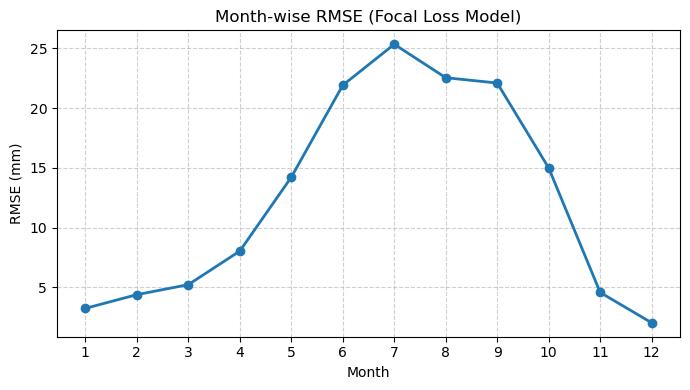

In [40]:
# Compute month-wise RMSE
month_rmse = (
    df_eval
    .groupby("month")
    .apply(lambda g: rmse(g.y.values, g.yhat.values))
    .sort_index()
)

# Plot
plt.figure(figsize=(7, 4))
plt.plot(
    month_rmse.index,
    month_rmse.values,
    marker="o",
    linewidth=2
)

plt.xticks(range(1, 13))
plt.xlabel("Month")
plt.ylabel("RMSE (mm)")
plt.title("Month-wise RMSE (Focal Loss Model)")
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

### Error Distribution Analysis

In [ ]:
# Error statistics
print("Error Statistics:")
print((df_eval['error']).describe(percentiles=[0.1, .2, .25, .3, .4, .5, .6, .7, .75, .8, .9, .95, .96, .97, .98, .99]).round(4))

In [ ]:
# Error histogram
plt.figure(figsize=(6, 4))
sns.histplot(df_eval['error'], bins=50, kde=True)
plt.xlabel("Prediction Error (ŷ − y)")
plt.title("Error Distribution (Focal Loss Model)")
plt.tight_layout()
plt.show()

### Rainy vs Non-Rainy Analysis

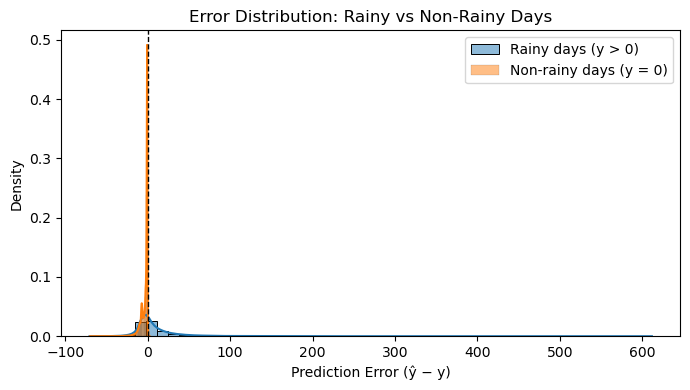

In [41]:
# Error histogram by rainfall regime
plt.figure(figsize=(7, 4))

sns.histplot(
    df_eval.loc[rainy_mask, "error"],
    bins=50,
    kde=True,
    color="tab:blue",
    label="Rainy days (y > 0)",
    stat="density",
)

sns.histplot(
    df_eval.loc[non_rainy_mask, "error"],
    bins=50,
    kde=True,
    color="tab:orange",
    label="Non-rainy days (y = 0)",
    stat="density",
)

plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("Prediction Error (ŷ − y)")
plt.title("Error Distribution: Rainy vs Non-Rainy Days")
plt.legend()
plt.tight_layout()
plt.show()

### Monsoon vs Non-Monsoon Analysis

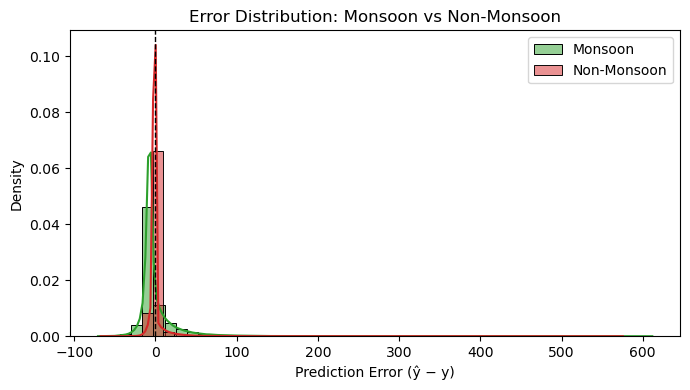

In [42]:
# Error histogram by season
plt.figure(figsize=(7, 4))

sns.histplot(
    df_eval.loc[monsoon_mask, "error"],
    bins=50,
    kde=True,
    color="tab:green",
    label="Monsoon",
    stat="density",
)

sns.histplot(
    df_eval.loc[non_monsoon_mask, "error"],
    bins=50,
    kde=True,
    color="tab:red",
    label="Non-Monsoon",
    stat="density",
)

plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("Prediction Error (ŷ − y)")
plt.title("Error Distribution: Monsoon vs Non-Monsoon")
plt.legend()
plt.tight_layout()
plt.show()

### Conditional RMSE Analysis

In [43]:
def conditional_rmse(mask, name):
    e = df_eval.loc[mask]
    return {
        "Regime": name,
        "RMSE": rmse(e.y, e.yhat),
        "MAE": mae(e.y, e.yhat),
        "Bias": bias(e.y, e.yhat),
        "Count": len(e)
    }

conditional_metrics = pd.DataFrame([
    conditional_rmse(df_eval.y == 0, "Non-rainy"),
    conditional_rmse((df_eval.y > 0) & (df_eval.y <= 10), "Light rain"),
    conditional_rmse((df_eval.y > 10) & (df_eval.y <= 50), "Moderate rain"),
    conditional_rmse(df_eval.y > 50, "Heavy rain"),
])

print("\nConditional RMSE by Rainfall Regime:")
print(conditional_metrics.round(4))


Conditional RMSE by Rainfall Regime:
          Regime       RMSE        MAE       Bias   Count
0      Non-rainy   5.635600   3.448000   3.447400  418964
1     Light rain   9.558200   6.869100   5.832600   83490
2  Moderate rain  17.204201  13.772100 -11.163600   67003
3     Heavy rain  81.472603  68.987198 -68.931999   15945


### Baseline Comparison

In [44]:
# Baseline models
yhat_zero = np.zeros_like(df_eval.y)
yhat_mean = np.full_like(df_eval.y, df_eval.y.mean())

baseline_table = pd.DataFrame({
    "Focal Loss Model": {
        "RMSE": rmse(df_eval.y, df_eval.yhat),
        "MAE": mae(df_eval.y, df_eval.yhat),
    },
    "Zero Predictor": {
        "RMSE": rmse(df_eval.y, yhat_zero),
        "MAE": mae(df_eval.y, yhat_zero),
    },
    "Mean Predictor": {
        "RMSE": rmse(df_eval.y, yhat_mean),
        "MAE": mae(df_eval.y, yhat_mean),
    },
}).T

print("\nBaseline Comparison:")
print(baseline_table.round(4))


Baseline Comparison:
                       RMSE     MAE
Focal Loss Model  15.825100  6.9027
Zero Predictor    18.398399  5.5978
Mean Predictor    17.526100  8.6384


### Scatter Plot: True vs Predicted

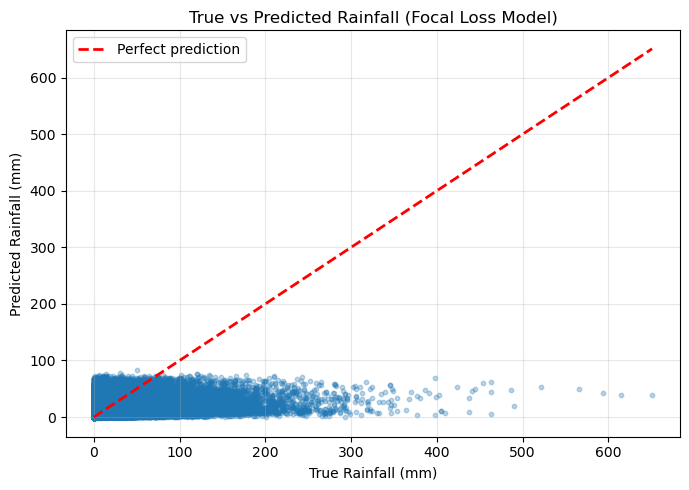

In [45]:
plt.figure(figsize=(7, 5))
plt.scatter(
    df_eval["y"],
    df_eval["yhat"],
    alpha=0.3,
    s=10
)

# Perfect prediction line
max_val = max(df_eval["y"].max(), df_eval["yhat"].max())
plt.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect prediction')

plt.xlabel("True Rainfall (mm)")
plt.ylabel("Predicted Rainfall (mm)")
plt.title("True vs Predicted Rainfall (Focal Loss Model)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Summary

In [46]:
summary_data = [
    {"Metric": "RMSE", "Value": overall_metrics["RMSE"]},
    {"Metric": "MAE", "Value": overall_metrics["MAE"]},
    {"Metric": "Bias", "Value": overall_metrics["Bias"]},
    {"Metric": "NRMSE", "Value": overall_metrics["NRMSE"]},
]

print(f"\n{'='*60}")
print(f"EXPERIMENT SUMMARY: FocalMSELoss (γ={FOCAL_GAMMA})")
print(f"{'='*60}")
print(f"Window Length: {L} days")
print(f"Horizon: {H} day")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS}")
print(f"Learning Rate: {LEARNING_RATE}")
print(f"Hidden Dimension: {HIDDEN_DIM}")
print(f"\nResults:")
print(pd.DataFrame(summary_data).to_string(index=False))
print(f"{'='*60}")


EXPERIMENT SUMMARY: FocalMSELoss (γ=2.0)
Window Length: 30 days
Horizon: 1 day
Batch Size: 64
Epochs: 10
Learning Rate: 0.001
Hidden Dimension: 128

Results:
Metric     Value
  RMSE 15.825139
   MAE  6.902724
  Bias  0.143830
 NRMSE  2.827031
